# 08 — Secondary dataset cross-validation (Credit Card Fraud)

Tests whether the framework generalises to a second dataset. Credit Card Fraud has **real fraud labels** (`Class`), so Module 1 is evaluated against genuine anomalies, no injection needed.

Note (limitation): the V1-V28 columns are anonymous PCA features with no business meaning, so Module 2's structural check is not business-meaningful here; we run the **statistical** drift check (KS test) on the numeric columns. Modules 1 and 3 run fully.

**Requires PyTorch** for the autoencoder (`pip install torch`).

In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
from scipy import stats
from xgboost import XGBClassifier
import module1_anomaly as m1
DATA_PATH = '../data/creditcard.csv'

In [2]:
df = pd.read_csv(DATA_PATH)
vcols = [f'V{i}' for i in range(1,29)]
df['log_amount'] = np.log1p(df['Amount'].clip(lower=0))
feat_cols = vcols + ['log_amount']
print('shape:', df.shape, '| fraud rate: %.3f%%' % (100*df.Class.mean()))

shape: (284807, 32) | fraud rate: 0.173%


## Module 1 — anomaly detection vs REAL fraud labels
Fit detectors on legitimate transactions (the clean reference), score all, evaluate against `Class`.

In [3]:
legit = df[df.Class==0]
scaler = StandardScaler().fit(legit[feat_cols].values)
X = scaler.transform(df[feat_cols].values)
Xref = scaler.transform(legit.sample(50_000, random_state=42)[feat_cols].values)
y = df['Class'].values
iso = m1.fit_isolation_forest(Xref); s_iso = m1.score_isolation_forest(iso, X)
lof = m1.fit_lof(Xref);             s_lof = m1.score_lof(lof, X)
sz, _ = m1.zscore_scores(X[:,-1], ref_values=Xref[:,-1])
import module1_autoencoder as ae            # autoencoder on the 29 features
autoenc = ae.train_autoencoder(Xref, epochs=20)
s_ae = ae.score_autoencoder(autoenc, X)
scores = {'Isolation Forest': s_iso, 'LOF': s_lof, 'Z-score (amount)': sz, 'Autoencoder': s_ae}
rows = [[nm, round(roc_auc_score(y,s),3), round(average_precision_score(y,s),3)] for nm,s in scores.items()]
pd.DataFrame(rows, columns=['detector','ROC-AUC','PR-AUC'])

,detector,ROC-AUC,PR-AUC
0,Isolation Forest,0.953,0.132
1,LOF,0.956,0.356
2,Z-score (amount),0.705,0.004
3,Autoencoder,0.956,0.521


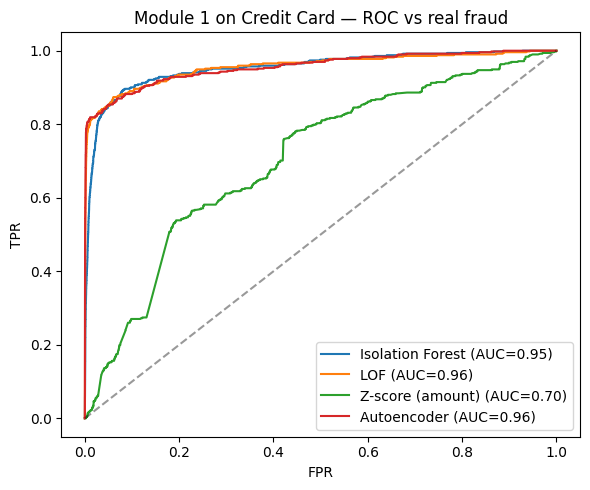

In [4]:
plt.figure(figsize=(6,5))
for nm,s in scores.items():
    fpr,tpr,_=roc_curve(y,s); plt.plot(fpr,tpr,label=f'{nm} (AUC={roc_auc_score(y,s):.2f})')
plt.plot([0,1],[0,1],'k--',alpha=0.4); plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('Module 1 on Credit Card — ROC vs real fraud'); plt.legend()
plt.tight_layout(); plt.savefig('../results/secondary_module1_roc.png', dpi=120); plt.show()

## Module 2 — statistical drift (first 24h vs second 24h)

In [5]:
half = df.Time.median(); a = df[df.Time<half]; b = df[df.Time>=half]
rows=[]
for col in vcols[:6]+['Amount']:
    ks,p = stats.ks_2samp(a[col].values, b[col].values)
    rows.append([col, round(ks,3), format(p,'.1e'), p<0.05])
pd.DataFrame(rows, columns=['column','ks_stat','p_value','drifted'])

,column,ks_stat,p_value,drifted
0,V1,0.416,0.0e+00,True
1,V2,0.039,4.0e-94,True
2,V3,0.511,0.0e+00,True
3,V4,0.171,0.0e+00,True
4,V5,0.265,0.0e+00,True
5,V6,0.114,0.0e+00,True
6,Amount,0.024,4.9e-35,True


## Module 3 — missing prediction (MAR on Amount, predict from V columns)

In [6]:
def mar(d, col, rate=0.10, seed=42):
    d=d.copy(); rng=np.random.default_rng(seed); n=int(len(d)*rate)
    w=(d[col].rank().values**2); w=w/w.sum()
    idx=rng.choice(d.index, size=n, replace=False, p=w)
    gt=pd.Series(False,index=d.index); gt.loc[idx]=True; d.loc[idx,col]=np.nan; return d,gt
train=df.sample(80_000,random_state=42).reset_index(drop=True)
test =df.sample(40_000,random_state=7).reset_index(drop=True)
trc,trg=mar(train,'Amount'); tec,teg=mar(test,'Amount',seed=43)
clf=XGBClassifier(n_estimators=200,max_depth=5,scale_pos_weight=9,random_state=42,eval_metric='logloss')
clf.fit(trc[vcols].fillna(0), trg.values)
p=clf.predict_proba(tec[vcols].fillna(0))[:,1]
print('Amount missing prediction ROC-AUC:', round(roc_auc_score(teg.values,p),3))

Amount missing prediction ROC-AUC: 0.692


## Reading the results
- **Module 1 generalises and detects REAL fraud** at ROC-AUC ~0.95 (Isolation Forest and LOF).
- **LOF works here but failed on IBM.** On IBM the anomalies were global amount-extremes (LOF's weak point); on Credit Card the fraud lives in the multi-dimensional V-space where LOF's local-density approach is strong. This shows exactly when each detector helps, and supports the multi-detector design.
- **Module 2's KS test** flags genuine drift between the two time windows.
- **Module 3** predicts missingness from the V-features (ROC-AUC ~0.69), comparable to IBM.
- **Limitation confirmed:** the PCA columns mean Module 2's structural check is not business-meaningful on this dataset, so only the statistical check is reported.